# Purpose

This notebook analyzes Non parametric modelling for reliability purposes.

The objective is to:
- Compute the f(t), h(t) and R(t) for a dataset
- Understand its role in modeling waiting times and aggregated failure processes

This kind of modelling takes on reference Modarres (2009) as a main source for equations and concepts.



# Equations

## Small samples

For the failure function $h(t)$ or $\lambda(t)$ (as presented in courses material) and their estimator:

$$
\lambda (t) = \frac{f(t)}{R(t)}
$$

$$
\hat{\lambda}(t_i) = \frac{1}{(n - i + 0.625)(t_{i+1} - t_i)}
$$

Reliability function (and its estimator parameter) can be defined as:

$$
R(t_i) = \frac{n-i}{n}
$$

$$
\hat{R}(t_i) = \frac{(n - i + 0.625)}{(n + 0.25)}
$$

Finally, the pdf could be written as:
$$
\hat{f}(t_i) = \frac{1}{(n + 0.25)(t_{i+1} - t(i))}
$$

In [3]:
# Default function for small datasets

def small_sample_lambda(i, n, t_i, t_i1,):
    return 1 / ((n - i + 0.625)*(t_i1 - t_i))

def small_sample_reliability(i, n):
    return (n - i + 0.625) / (n + 0.25)

def small_pdf(n, t_i, t_i1):
    return 1 / ((n + 0.25)*(t_i1 - t_i))


# Big samples

Whenever a sample is over $N > 25$ then, we should use the following equations:

$$
\hat{R}(t_i) = \frac{N_s(t_i)}{N}
$$

$$
\hat{f}(t_i) = \frac{N_f(t_i)}{N\Delta t}
$$

$$
\hat{\lambda}(t_i) = \frac{N_f(t_i)}{N_s(t_i)\Delta t}
$$

In [5]:
# Imports required for manipulating the datasets (outside functions scope)
import numpy as np
import pandas as pd

# Functions for big samples
def big_sample_reliability(N_s, N):
    return N_s / N

def big_sample_pdf(N_f, N, Delta_t):
    return N_f / (N * Delta_t)

def big_sample_lambda(N_f, N_s, Delta_t):
    return N_f / (N_s * Delta_t)

def big_sample_cumsum(N_f, total_items):
    cumulative_failures = np.cumsum(N_f)
    return np.concatenate(([total_items], total_items - cumulative_failures[:-1]))

## Example 3.7

Times to failure for an electrical device are obtained during three stages of the component’s life. 
The first stage represents the infant mortality of the component; the second stage represents 
chance failures; and the third stage represents the wear out period. Plot the failure rate for this 
component using the data provided below.

In [12]:
# Example 3.7 Solution

# input data
t_beg = np.array([0, 20, 40, 60, 80, 100, 120])
t_end = np.array([20, 40, 60, 80, 100, 120, 140])
total_components = 150
Nf = np.array([79, 37, 15, 6, 2, 1, 10])

# Counting the NS, is the cumulative sum of the failures,
# and then we store the amount of surviving components at the BEGINNING of the interval,
# thus for our example, [150, 150-71, ... and so on]
cumulative_failures = np.cumsum(Nf)
Ns = np.concatenate(([total_components], total_components - cumulative_failures[:-1]))
# function implement as big_sample_cumsum(Nf, total_components)
# Ns = big_sample_cumsum(Nf, total_components)
# manual calculation preserve for purposes of understanding the process, but the function is more efficient and less error-prone.

# Time interval
Delta_t = t_end - t_beg

# Columns failure rate, reliability and pdf
lambda_3_7 = big_sample_lambda(Nf, Ns, Delta_t)
reliability_3_7 = big_sample_reliability(Ns, total_components)
pdf_3_7 = big_sample_pdf(Nf, total_components, Delta_t)

example_3_7_solution = pd.DataFrame({
    "t_beg": t_beg,
    "t_end": t_end,
    "Nf": Nf,
    "Ns": Ns,
    "Delta_t": Delta_t,
    "lambda": lambda_3_7,
    "reliability": reliability_3_7,
    "pdf": pdf_3_7
})
print(example_3_7_solution)


   t_beg  t_end  Nf   Ns  Delta_t    lambda  reliability       pdf
0      0     20  79  150       20  0.026333     1.000000  0.026333
1     20     40  37   71       20  0.026056     0.473333  0.012333
2     40     60  15   34       20  0.022059     0.226667  0.005000
3     60     80   6   19       20  0.015789     0.126667  0.002000
4     80    100   2   13       20  0.007692     0.086667  0.000667
5    100    120   1   11       20  0.004545     0.073333  0.000333
6    120    140  10   10       20  0.050000     0.066667  0.003333


## Exercise 3.10

The following time to failure data are found when 158 transformer units are put under test.  Use a non-
parametric method to estimate f(t), h(t), and R(t) of the transformers.  No failures are observed prior 
to 1,750 hours.

| Time Interval | Frequency |
|--------------|----------|
| 2250         | 17       |
| 2750         | 54       |
| 3250         | 27       |
| 3750         | 17       |
| 4250         | 19       |
| 5000         | 24       |

In [13]:
# This is a big sample problem, as N = 156
# then N > 25 is TRUE

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

time_interval = np.array([0, 1750, 2250, 2750, 3250, 3750, 4250])
failure_count = np.array([17, 54, 27, 17, 19, 24])

total_transformers = failure_count.sum()
t_i = time_interval[:-1]
t_i1 = time_interval[1:]
i = np.arange(1, len(time_interval))
n = len(i)
Ns = big_sample_cumsum(failure_count, total_transformers)
Delta_t = t_i1 - t_i

lambda_values = big_sample_lambda(N_f=failure_count, N_s=Ns, Delta_t=Delta_t)
reliability_values = big_sample_reliability(N_s=Ns, N=total_transformers)
pdf_values = big_sample_pdf(N_f=failure_count, N=total_transformers, Delta_t=Delta_t)

print(failure_count[0]/(Ns[0]*Delta_t[0]))

exercise_3_10_df = pd.DataFrame({
    'Time Interval Start': t_i,
    'Time Interval End': t_i1,
    'Failure Count': failure_count,
    'Survival Count': Ns,
    'Lambda': lambda_values,
    'Reliability': reliability_values,
    'PDF': pdf_values
})

# Require for correct displaying
from IPython.display import display

display(
    exercise_3_10_df.style.format({
        'Lambda': '{:.2e}',
        'PDF': '{:.2e}',
        'Reliability': '{:.4f}'
    })
)

# Avoid using print() on Jupyter as it does not use the style layer
# exercise_3_10_df


6.148282097649186e-05


,Time Interval Start,Time Interval End,Failure Count,Survival Count,Lambda,Reliability,PDF
0,0,1750,17,158,6.15e-05,1.0000,6.15e-05
1,1750,2250,54,141,7.66e-04,0.8924,6.84e-04
2,2250,2750,27,87,6.21e-04,0.5506,3.42e-04
3,2750,3250,17,60,5.67e-04,0.3797,2.15e-04
4,3250,3750,19,43,8.84e-04,0.2722,2.41e-04
5,3750,4250,24,24,2.00e-03,0.1519,3.04e-04


## Exercise 3.12

A test of 25 integrated circuits over 500h yields the following data:

|Time interval|Number of failures|
|-------------|------------------|
|0-100|10|
|100-200|7|
|200-300|3|
|300-400|3|
|400-500|2|

Plot the pd, hazard rate, and reliability function for each interval of these integrated circuits using a non parametric method.

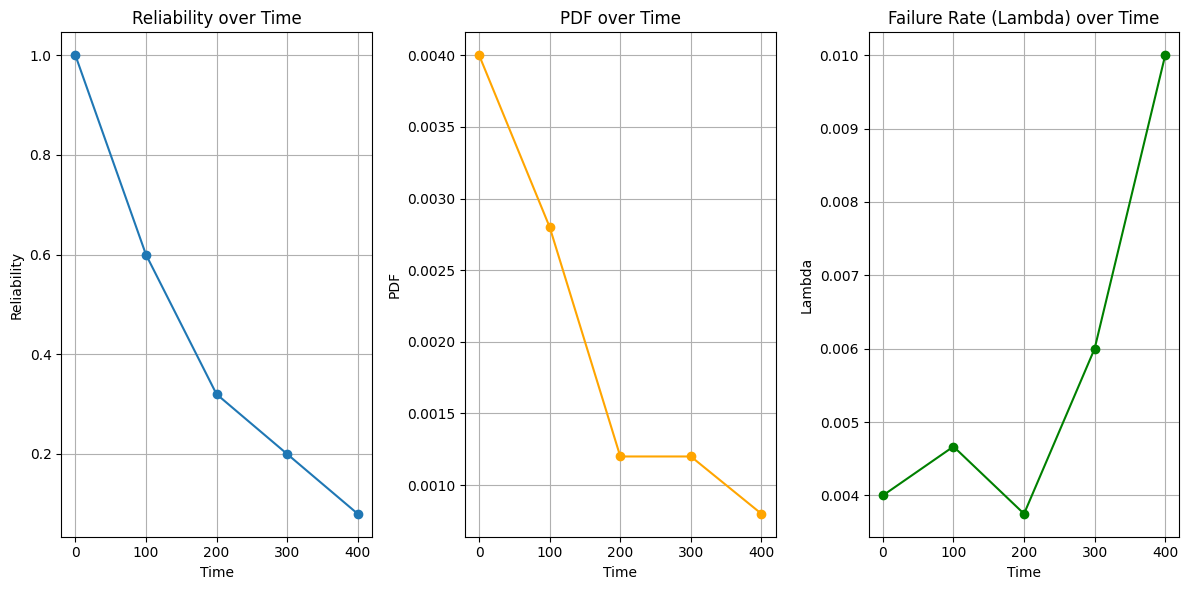

,Interval Start,Interval End,Failure Count,Survival Count,Lambda,Reliability,PDF
0,0,100,10,25,0.004000,1.00,0.0040
1,100,200,7,15,0.004667,0.60,0.0028
2,200,300,3,8,0.003750,0.32,0.0012
3,300,400,3,5,0.006000,0.20,0.0012
4,400,500,2,2,0.010000,0.08,0.0008


In [9]:
# Main imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Big dataset exercise 3.12

dataset = np.array([10, 7, 3, 3, 2])
t_i = np.array([0, 100, 200, 300, 400, 500])
n = dataset.sum()
Ns = big_sample_cumsum(dataset, total_items=n)
t_i1 = t_i[1:] # Interval beginning
t_i = t_i[:-1] # Interval end

# Calculate lambda, reliability, and pdf for each interval
lambdas = big_sample_lambda(N_f=dataset, N_s=Ns, Delta_t=t_i1 - t_i)
reliabilities = big_sample_reliability(N_s=Ns, N=n)
pdfs = big_sample_pdf(N_f=dataset, N=n, Delta_t=t_i1 - t_i)

dataset_pd = pd.DataFrame({
    'Interval Start': t_i,
    'Interval End': t_i1,
    'Failure Count': dataset,
    'Survival Count': Ns,
    'Lambda': lambdas,
    'Reliability': reliabilities,
    'PDF': pdfs
})

plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(t_i, reliabilities, marker='o')
plt.title('Reliability over Time')
plt.xlabel('Time')
plt.ylabel('Reliability')
plt.grid()
plt.subplot(1, 3, 2)
plt.plot(t_i, pdfs, marker='o', color='orange')
plt.title('PDF over Time')
plt.xlabel('Time')
plt.ylabel('PDF')
plt.grid()
plt.subplot(1, 3, 3)
plt.plot(t_i, lambdas, marker='o', color='green')
plt.title('Failure Rate (Lambda) over Time')
plt.xlabel('Time')
plt.ylabel('Lambda')
plt.grid()
plt.tight_layout()
plt.show()


dataset_pd